# 01 — Exploratory Data Analysis: oHCM Cohort & Camzyos Adoption

**IC question:** Who are the oHCM patients in this dataset, who is initiating Camzyos, and what does their symptom profile look like?

This notebook establishes:
1. oHCM cohort identification under two definitions (loose vs. strict)
2. Mavacamten prescription patterns — frequency, persistence, fill gaps
3. Temporal adoption curve
4. Symptom burden among Camzyos patients (dyspnea, HF, fatigue, cardiology E&M)

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.style import (
    C_ARCH,
    C_OBS,
    C_PRED,
    INK_PRI,
    INK_SEC,
    SURFACE,
    style_ax,
)

DATA_DIR = Path("../synthetic_data")
np.random.seed(42)

In [2]:
patients = pd.read_csv(DATA_DIR / "patients.csv")
diagnoses = pd.read_csv(DATA_DIR / "diagnoses.csv", parse_dates=["date"])
procedures = pd.read_csv(DATA_DIR / "procedures.csv", parse_dates=["date"])
prescriptions = pd.read_csv(DATA_DIR / "prescriptions.csv", parse_dates=["date"])
enrollment = pd.read_csv(DATA_DIR / "enrollment.csv")
code_dict = pd.read_csv(DATA_DIR / "code_dictionary.csv")

print(f"Patients:      {len(patients):,}")
print(f"Diagnoses:     {len(diagnoses):,}")
print(f"Procedures:    {len(procedures):,}")
print(f"Prescriptions: {len(prescriptions):,}")
print(f"Enrollment:    {len(enrollment):,}")
print(f"Code dict:     {len(code_dict):,}")

Patients:      30,000
Diagnoses:     3,307,924
Procedures:    1,812,612
Prescriptions: 1,166,961
Enrollment:    1,274,810
Code dict:     775


---
## 1. oHCM Cohort Identification

Two definitions, compared side-by-side:

| Definition | Rule |
|---|---|
| **Loose** | ≥1 claim with ICD-10 I42.1 |
| **Strict** | (≥2 claims with I42.1, ≥30 days apart) OR (≥1 I42.2 + ≥1 I42.1) |

The strict definition reduces false positives from rule-out diagnoses or coding errors.

In [3]:
# --- Loose definition: >= 1 I421 claim ---
ohcm_dx = diagnoses[diagnoses["dx_code"] == "I421"].copy()
cohort_loose = set(ohcm_dx["patient_id"].unique())
print(f"Loose cohort (≥1 I421 claim): {len(cohort_loose):,} patients")

Loose cohort (≥1 I421 claim): 2,506 patients


In [4]:
# --- Strict definition ---
# Path A: ≥2 I421 claims, ≥30 days apart
i421_claims = ohcm_dx.sort_values(["patient_id", "date"])
i421_claims["prev_date"] = i421_claims.groupby("patient_id")["date"].shift(1)
i421_claims["days_gap"] = (i421_claims["date"] - i421_claims["prev_date"]).dt.days

path_a = set(i421_claims.loc[i421_claims["days_gap"] >= 30, "patient_id"].unique())
print(f"Path A (≥2 I421, ≥30d apart): {len(path_a):,} patients")

# Path B: ≥1 I422 AND ≥1 I421
has_i422 = set(diagnoses.loc[diagnoses["dx_code"] == "I422", "patient_id"].unique())
has_i421 = cohort_loose
path_b = has_i422 & has_i421
print(f"Path B (I422 + I421):          {len(path_b):,} patients")

cohort_strict = path_a | path_b
print(f"\nStrict cohort (A ∪ B):         {len(cohort_strict):,} patients")
print(f"Loose − Strict (dropped):      {len(cohort_loose - cohort_strict):,} patients")

Path A (≥2 I421, ≥30d apart): 1,919 patients


Path B (I422 + I421):          1,675 patients

Strict cohort (A ∪ B):         1,969 patients
Loose − Strict (dropped):      537 patients


In [5]:
def cohort_summary(patient_ids, label):
    df = patients[patients["patient_id"].isin(patient_ids)].copy()
    df["age_2022"] = 2022 - df["birth_year"]
    return pd.Series(
        {
            "label": label,
            "n": len(df),
            "age_median": df["age_2022"].median(),
            "age_q25": df["age_2022"].quantile(0.25),
            "age_q75": df["age_2022"].quantile(0.75),
            "pct_female": (df["sex"] == "F").mean() * 100,
        }
    )


mav_patients = set(
    prescriptions.loc[prescriptions["rx_code"] == "Mavacamten", "patient_id"].unique()
)
print(
    f"Camzyos capture: {len(mav_patients & cohort_loose)}/{len(mav_patients)} in loose, "
    f"{len(mav_patients & cohort_strict)}/{len(mav_patients)} in strict\n"
)

summary = pd.DataFrame(
    [
        cohort_summary(cohort_loose, "Loose (≥1 I421)"),
        cohort_summary(cohort_strict, "Strict"),
        cohort_summary(mav_patients, "Camzyos patients"),
    ]
).set_index("label")

print("Cohort demographics (age as of 2022):")
display(summary)

Camzyos capture: 150/166 in loose, 150/166 in strict

Cohort demographics (age as of 2022):


,n,age_median,age_q25,age_q75,pct_female
label,,,,,
Loose (≥1 I421),2506,70.0,57.00,79.0,52.154828
Strict,1969,69.0,56.00,79.0,53.529711
Camzyos patients,166,70.0,57.25,79.0,56.024096


---
## 2. Mavacamten Prescription Patterns

For each Camzyos patient: how many fills, what supply (30d vs 90d), and are there gaps suggesting discontinuation?

In [6]:
mav_rx = prescriptions[prescriptions["rx_code"] == "Mavacamten"].copy()
mav_rx = mav_rx.sort_values(["patient_id", "date"])

print(f"Total Mavacamten fills: {len(mav_rx):,}")
print(f"Unique patients:       {mav_rx['patient_id'].nunique()}")
print("\nDays supply distribution:")
print(mav_rx["days_supply"].value_counts().to_string())

Total Mavacamten fills: 1,472
Unique patients:       166

Days supply distribution:
days_supply
30    1142
90     330


Fills per patient:


,count,mean,std,min,25%,50%,75%,max
n_fills,166.0,8.86747,4.607691,1.0,5.0,9.0,13.0,18.0


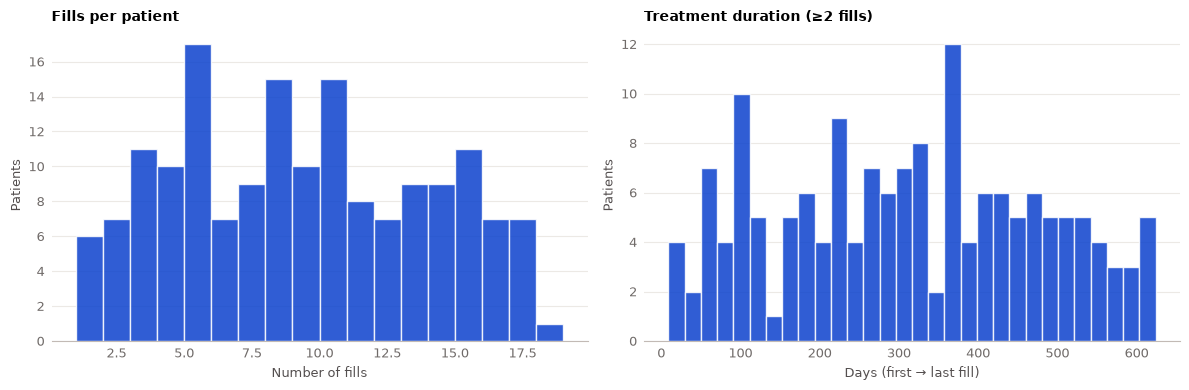

In [7]:
mav_per_patient = (
    mav_rx.groupby("patient_id")
    .agg(
        n_fills=("date", "count"),
        first_fill=("date", "min"),
        last_fill=("date", "max"),
        pct_90d=("days_supply", lambda x: (x == 90).mean() * 100),
    )
    .reset_index()
)
mav_per_patient["duration_days"] = (
    mav_per_patient["last_fill"] - mav_per_patient["first_fill"]
).dt.days

print("Fills per patient:")
display(mav_per_patient["n_fills"].describe().to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.set_facecolor(SURFACE)

axes[0].hist(
    mav_per_patient["n_fills"],
    bins=range(1, mav_per_patient["n_fills"].max() + 2),
    color=C_OBS,
    edgecolor=SURFACE,
    alpha=0.85,
)
axes[0].set_xlabel("Number of fills", fontsize=9, color=INK_SEC)
axes[0].set_ylabel("Patients", fontsize=9, color=INK_SEC)
axes[0].set_title("Fills per patient", fontsize=10, fontweight="bold", color=INK_PRI, loc="left")
style_ax(axes[0])

axes[1].hist(
    mav_per_patient.loc[mav_per_patient["duration_days"] > 0, "duration_days"],
    bins=30,
    color=C_OBS,
    edgecolor=SURFACE,
    alpha=0.85,
)
axes[1].set_xlabel("Days (first → last fill)", fontsize=9, color=INK_SEC)
axes[1].set_ylabel("Patients", fontsize=9, color=INK_SEC)
axes[1].set_title(
    "Treatment duration (≥2 fills)", fontsize=10, fontweight="bold", color=INK_PRI, loc="left"
)
style_ax(axes[1])

plt.tight_layout()
plt.show()

---
## 3. Mavacamten Prescriptions Over Time

Two views:
- **New initiations per month** (first fill per patient) — the actual adoption signal
- **Total fills per month** — confounds new starts with persistence/refills

In [8]:
mav_rx["year_month"] = mav_rx["date"].dt.to_period("M")

# Total fills per month
total_fills = mav_rx.groupby("year_month").size().rename("total_fills")

# New initiations per month (first fill per patient)
first_fills = mav_rx.groupby("patient_id")["date"].min().reset_index()
first_fills["year_month"] = first_fills["date"].dt.to_period("M")
new_starts = first_fills.groupby("year_month").size().rename("new_initiations")

# Cumulative initiations
cumulative = new_starts.cumsum().rename("cumulative_patients")

monthly = pd.concat([total_fills, new_starts, cumulative], axis=1).fillna(0).astype(int)
print("Monthly Mavacamten summary:")
display(monthly)

Monthly Mavacamten summary:


,total_fills,new_initiations,cumulative_patients
year_month,,,
2022-04,7,7,7
2022-05,14,10,17
2022-06,16,6,23
2022-07,25,7,30
2022-08,34,10,40
2022-09,41,9,49
2022-10,52,10,59
2022-11,50,5,64
2022-12,67,18,82


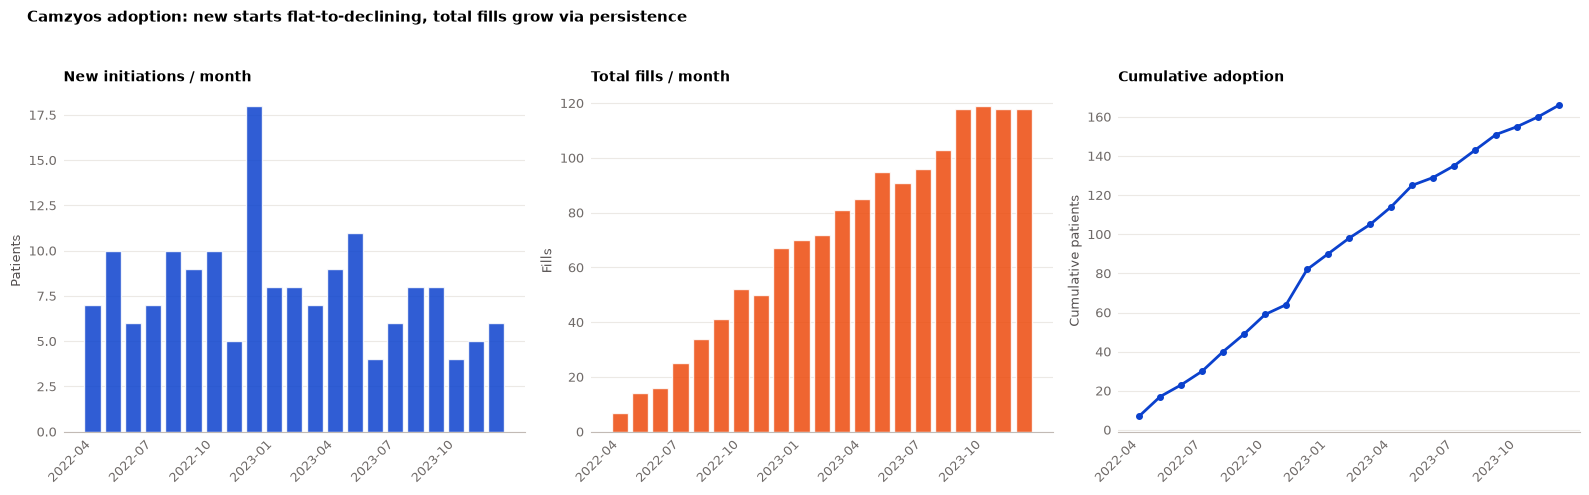

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.set_facecolor(SURFACE)

x = range(len(monthly))
labels = [str(p) for p in monthly.index]

axes[0].bar(x, monthly["new_initiations"], color=C_OBS, edgecolor=SURFACE, alpha=0.85)
axes[0].set_xticks(x[::3])
axes[0].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[0].set_ylabel("Patients", fontsize=9, color=INK_SEC)
axes[0].set_title(
    "New initiations / month", fontsize=10, fontweight="bold", color=INK_PRI, loc="left"
)

axes[1].bar(x, monthly["total_fills"], color=C_PRED, edgecolor=SURFACE, alpha=0.85)
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[1].set_ylabel("Fills", fontsize=9, color=INK_SEC)
axes[1].set_title("Total fills / month", fontsize=10, fontweight="bold", color=INK_PRI, loc="left")

axes[2].plot(x, monthly["cumulative_patients"], color=C_OBS, marker="o", markersize=4, linewidth=2)
axes[2].set_xticks(x[::3])
axes[2].set_xticklabels(labels[::3], rotation=45, ha="right")
axes[2].set_ylabel("Cumulative patients", fontsize=9, color=INK_SEC)
axes[2].set_title("Cumulative adoption", fontsize=10, fontweight="bold", color=INK_PRI, loc="left")

for ax in axes:
    style_ax(ax)

fig.suptitle(
    "Camzyos adoption: new starts flat-to-declining, total fills grow via persistence",
    fontsize=11,
    fontweight="bold",
    color=INK_PRI,
    x=0.02,
    ha="left",
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

---
## 4. Symptom Burden Among Camzyos Patients

We proxy NYHA II/III symptom severity using claims codes:

| Symptom proxy | ICD-10 codes |
|---|---|
| Dyspnea | R0600, R0602, R0609 |
| Heart failure | I50xx (all) |
| Fatigue | R5383, R531, R5381 |
| Cardiology E&M (high complexity) | 99214, 99215, 99204, 99205 |

In [10]:
DYSPNEA_CODES = ["R0600", "R0602", "R0609"]
HF_CODES = [c for c in diagnoses["dx_code"].unique() if str(c).startswith("I50")]
FATIGUE_CODES = ["R5383", "R531", "R5381"]
CARDIO_EM_CODES = ["99214", "99215", "99204", "99205"]


def symptom_prevalence(patient_ids, label):
    """Compute symptom prevalence (%) for a set of patients."""
    dx_sub = diagnoses[diagnoses["patient_id"].isin(patient_ids)]
    px_sub = procedures[procedures["patient_id"].isin(patient_ids)]
    n = len(patient_ids)
    return pd.Series(
        {
            "group": label,
            "n": n,
            "Dyspnea": dx_sub[dx_sub["dx_code"].isin(DYSPNEA_CODES)]["patient_id"].nunique()
            / n
            * 100,
            "Heart failure": dx_sub[dx_sub["dx_code"].isin(HF_CODES)]["patient_id"].nunique()
            / n
            * 100,
            "Fatigue": dx_sub[dx_sub["dx_code"].isin(FATIGUE_CODES)]["patient_id"].nunique()
            / n
            * 100,
            "Cardiology E&M": px_sub[px_sub["px_code"].isin(CARDIO_EM_CODES)][
                "patient_id"
            ].nunique()
            / n
            * 100,
        }
    )


symptom_df = pd.DataFrame(
    [
        symptom_prevalence(mav_patients, "Camzyos"),
        symptom_prevalence(cohort_loose - mav_patients, "oHCM (no Camzyos)"),
        symptom_prevalence(cohort_strict - mav_patients, "oHCM strict (no Camzyos)"),
    ]
).set_index("group")

print("Symptom prevalence (% with ≥1 claim, full observation period):")
display(symptom_df.round(1))

Symptom prevalence (% with ≥1 claim, full observation period):


,n,Dyspnea,Heart failure,Fatigue,Cardiology E&M
group,,,,,
Camzyos,166,77.1,77.1,41.0,97.6
oHCM (no Camzyos),2356,71.6,78.8,43.5,94.4
oHCM strict (no Camzyos),1819,69.3,75.5,39.7,94.3


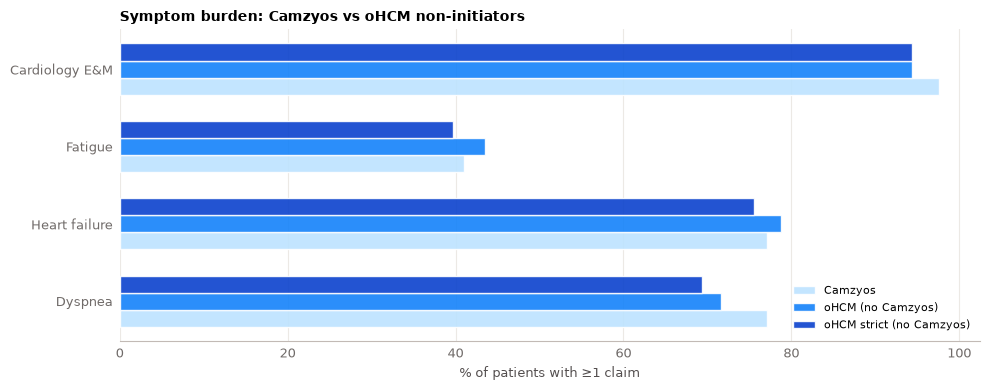

In [11]:
pct_cols = ["Dyspnea", "Heart failure", "Fatigue", "Cardiology E&M"]
plot_data = symptom_df[pct_cols]

fig, ax = plt.subplots(figsize=(10, 4))
fig.set_facecolor(SURFACE)

y_pos = np.arange(len(pct_cols))
bar_h = 0.22
colors = C_ARCH[:3]

for i, (group, row) in enumerate(plot_data.iterrows()):
    ax.barh(
        y_pos + i * bar_h,
        row.values,
        height=bar_h,
        color=colors[i],
        edgecolor=SURFACE,
        alpha=0.90,
        label=group,
    )

ax.set_yticks(y_pos + bar_h)
ax.set_yticklabels(pct_cols)
ax.set_xlabel("% of patients with ≥1 claim", fontsize=9, color=INK_SEC)
ax.set_title(
    "Symptom burden: Camzyos vs oHCM non-initiators",
    fontsize=10,
    fontweight="bold",
    color=INK_PRI,
    loc="left",
)
ax.legend(fontsize=8, frameon=False, loc="lower right")
style_ax(ax, grid_axis="x")

plt.tight_layout()
plt.show()